# **Assignment 4- Transformer Embeddings, Topic Modeling, and Soft Clustering**

-------------

## **Set-Up**

Here, we will focus on importing all the libraries needed to run this assignment. Additionally, we will load the data and store it in two distinct variables:

- `data_labels` — this will contain the data with all of our manual labels
- `data_og` — this will contain the original dataset with 6,314 web page records initially

In [1]:
# Following Libraries are required to run this notebook
try :
    import numpy as np 
    import pandas as pd
    from sklearn.metrics.pairwise import cosine_similarity
    from sklearn.feature_extraction.text import CountVectorizer
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
    import matplotlib.pyplot as plt
    import seaborn as sns
    import time
    import os
    from dotenv import load_dotenv
    from sentence_transformers import SentenceTransformer
    from huggingface_hub import HfApi
    import google.genai as gai 
    from umap import UMAP
    import re
    import torch
    import gc

    print("All the libraries are loaded successfully !!")

except Exception as e:
    print(" Your env doesn't include all the mentioned libraries:\n",e)


/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All the libraries are loaded successfully !!


In [2]:
# loading the data
data_label = pd.read_csv("data/english_pages_metadata_clean_with_labels.csv")

data_og = pd.read_csv("data/dataset_with_assignments.csv")

In [3]:
print("--")
print("List of columns in the original dataset")
print("--"*50)
print(data_og.columns)

--
List of columns in the original dataset
----------------------------------------------------------------------------------------------------
Index(['page_id', 'url', 'domain', 'tld', 'date', 'word_count', 'text_length',
       'sentence_count', 'paragraph_count', 'avg_word_length', 'path_depth',
       'text', 'full_text', 'assigned_to', 'manual_label'],
      dtype='str')


In [4]:
# Description of the original data
print("--"*50)
print("Original Data Description")
print("--"*50)
data_og.describe()

----------------------------------------------------------------------------------------------------
Original Data Description
----------------------------------------------------------------------------------------------------


,page_id,word_count,text_length,sentence_count,paragraph_count,avg_word_length,path_depth,manual_label
count,6314.000000,6314.000000,6.314000e+03,6314.000000,6314.000000,6314.000000,6314.000000,0.0
mean,4196.268609,1029.227114,7.092383e+03,59.067152,1.128286,7.040988,2.355084,NaN
std,2372.410287,2247.213005,2.990320e+04,427.019873,2.290003,12.457661,1.475493,NaN
min,1.000000,51.000000,2.590000e+02,1.000000,1.000000,3.490000,0.000000,NaN
25%,2140.250000,277.000000,1.809000e+03,11.000000,1.000000,6.100000,1.000000,NaN
50%,4274.500000,584.000000,3.785000e+03,24.000000,1.000000,6.460000,2.000000,NaN
75%,6241.750000,1149.000000,7.556250e+03,51.000000,1.000000,6.880000,3.000000,NaN
max,8268.000000,86776.000000,2.099836e+06,31928.000000,117.000000,488.220000,29.000000,NaN


In [5]:
print("--")
print("List of columns in the labled dataset")
print("--"*50)
print(data_label.columns)

--
List of columns in the labled dataset
----------------------------------------------------------------------------------------------------
Index(['page_id', 'assigned_to', 'manual_label', 'manual_label_clean',
       'manual_label_final', 'full_text', '_merge'],
      dtype='str')


In [6]:
# Description of the labeled data
print("--"*50)
print("Original Data Description")
print("--"*50)
data_label.describe()

----------------------------------------------------------------------------------------------------
Original Data Description
----------------------------------------------------------------------------------------------------


,page_id
count,596.000000
mean,675.904362
std,449.207144
min,1.000000
25%,356.250000
50%,620.500000
75%,977.250000
max,2060.000000


In [7]:
# Label distribution of the labeled data
print("--"*50)
print("Label Distribution")
print("--"*50)
print(data_label["manual_label_final"].value_counts())

----------------------------------------------------------------------------------------------------
Label Distribution
----------------------------------------------------------------------------------------------------
manual_label_final
OTHER               158
BLOG                123
ECOMMERCE           114
EDUCATION            61
NEWS                 47
FORUM/DISCUSSION     46
TECHNICAL            34
GOVERNMENT           13
Name: count, dtype: int64


---------

## **Text Preprocessing**

In this section, the primary focus is on cleaning the text data.Identifying and removing these characters early is important, as they can cause issues later in the pipeline and can negatively impact stability and compatibility. The primary goal here is to retain ASCII characters, such as English letters, numbers, and common punctuation (e.g., '(', ')', '[', ']', '+', '-', ' '), while ensuring that the existing structure of the text remains unchanged.

In [8]:
# list of currency symbols (few of them might not be present, but still we will keep it)
currency_symbols = [
    # Paired (Multi-character) symbols (Longest first)
    'USD','AU$', 'C$', 'NZ$', 'HK$', 'S$', 'US$', 'NT$', 'MX$', 'R$', 'zł', 'Kč','₨',
    'kr', 'Ft', 'ден', 'р.', 'лв', '₡', '₢', '₣', '₥', 

    # Single character symbols (Specific before generic)
    '€', '£', '¥', '元', '₹', '฿', '₩', '₽', '₪', '₺', '₦', '₵', '₫', 
    '₱', '₭', '₮', '₼', '₸', '₴', '៛', '₲', '₡', '₾', '֏', '﷼', 'Ξ', 'Ł', '$'
]

curr_symbols = ''.join(re.escape(s) for s in currency_symbols)

In [9]:
# Text cleaning function
def full_text_clean(text):

    # Regex pattern for extracting emails
    email_pattern = r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b'

    # Regex pattern for extracting phone numbers (various formats)
    phone_pattern = r'\b(?:\+\d{1,3}[-\s]?)?(?:\(\d{3}\)|\d{3})[-\s]?\d{3,4}[-\s]\d{4}\b'

    # Regex pattern for extracting dates (various formats)
    date_pattern = r'\b(?:\d{4}[-.]\d{2}[-.]\d{2}|\d{2}[-/]\d{2}[-/]\d{4}|(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Sept|Oct|Nov|Dec)[a-z]*\s\d{1,2},\s\d{4}|\d{1,2}\s(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Sept|Oct|Nov|Dec)[a-z]*\.?\s\d{4})\b'

    # Regex pattern for extracting URLs
    url_pattern = r'https?://\S+|www\.\S+'

    # Applying the patterns on the text
    text = re.sub(email_pattern, '', text)  # Remove email addresses from the text
    text = re.sub(phone_pattern, '', text)  # Remove phone numbers from the text
    text = re.sub(date_pattern, '', text)  # Remove dates from the text
    text = re.sub(url_pattern, '', text)  # Remove URLs from the text
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)  # Reduce sequences of three or more identical characters to two
    text = re.sub(r'[_\-/|]', ' ', text)  # Replace underscores, hyphens, forward slashes, and pipes with spaces
    text = text.lower()  # Convert all characters in the text to lowercase
    text = re.sub(rf"[^a-z{curr_symbols}\s]", '', text)  # Remove characters that are not letters, currency symbols, or spaces
    text=re.sub(r'[^\w\s]+', '', text)  # Remove punctuation and special characters, keeping only word characters and spaces
    text = re.sub(r'[\n\r\t]+', ' ', text)

    return text

In [10]:
# Data Cleaning and Preprocessing
data_label['cleaned_text'] = data_label['full_text'].apply(full_text_clean)
data_og['cleaned_text'] = data_og['full_text'].apply(full_text_clean)

print("--"*50)
print("Data Cleaning Complete!")
print("--"*50)

----------------------------------------------------------------------------------------------------
Data Cleaning Complete!
----------------------------------------------------------------------------------------------------


In [11]:
# Printing cleaned original data
print("--"*50)
print("Cleaned Original Data")
print("--"*50)
# Displaying the cleaned text
data_og[['page_id', 'cleaned_text']]

----------------------------------------------------------------------------------------------------
Cleaned Original Data
----------------------------------------------------------------------------------------------------


,page_id,cleaned_text
0,1,best resume templates ready to download k...
1,4,sh sz hk stock connect quick quote market ipho...
2,6,ada amiga demoscene archive ada amiga demoscen...
3,7,time mortality and memory blog from trends w...
4,8,afr news jurisdictionary how your constitutio...
...,...,...
6309,8259,april newsletter zettel family farms skip to...
6310,8261,ponds bright beauty spot less glow facewash g ...
6311,8262,understanding bitcoin and its market trends ho...
6312,8264,woman and dog wood figurine z mans wood art ...


In [12]:
print("--"*50)
print("Cleaned Labeled Data")
print("--"*50)
# Displaying the cleaned text
data_label[['page_id', 'cleaned_text', "manual_label_final"]]

----------------------------------------------------------------------------------------------------
Cleaned Labeled Data
----------------------------------------------------------------------------------------------------


,page_id,cleaned_text,manual_label_final
0,655.0,fall arrest and work positioning harness alli...,ECOMMERCE
1,656.0,vermont mountain eats jay peak all mountain ...,BLOG
2,657.0,booking report for bulloch county allongeor...,NEWS
3,658.0,is pickleball easier than tennis allracket s...,BLOG
4,661.0,account executive auto finance greater seatt...,OTHER
...,...,...,...
591,489.0,blog post archives th voyagemystic seaport t...,BLOG
592,490.0,kids bike pedals collection d model in bicycle...,ECOMMERCE
593,491.0,patchcrafts february patchcrafts the place to...,BLOG
594,493.0,fatal error uncaught mysqli sql exception tabl...,OTHER


In [13]:
# Random test for chatacter length in Original data
idx = np.random.randint(0, 6314)
print("--"*50)
print(f"Text Field ({idx}) \n-- Total Characters length before cleaning: {len(data_og.loc[idx, 'full_text'])} \n-- Total Character Length  after cleaning: {len(data_og.loc[idx, 'cleaned_text'])}")
print("--"*50)

----------------------------------------------------------------------------------------------------
Text Field (5485) 
-- Total Characters length before cleaning: 4841 
-- Total Character Length  after cleaning: 4344
----------------------------------------------------------------------------------------------------


In [14]:
# Random test for chatacter length in Labeled data
idx = np.random.randint(0, 596)
print("--"*50)
print(f"Text Field ({idx}) \n-- Total Characters length before cleaning: {len(data_label.loc[idx, 'full_text'])} \n-- Total Character Length  after cleaning: {len(data_label.loc[idx, 'cleaned_text'])}")
print("--"*50)

----------------------------------------------------------------------------------------------------
Text Field (183) 
-- Total Characters length before cleaning: 17776 
-- Total Character Length  after cleaning: 14473
----------------------------------------------------------------------------------------------------


In [15]:
# Extracting all the sentences from the Original data
sentences = data_og['cleaned_text'].to_list()
# Find total number of tokens
total_tokens = sum(len(s) for s in sentences)

# Find average number of tokens per document
avg_tokens = np.mean([len(s) for s in sentences])

print("--"*50)
print("Preprocessing completed. Sample of cleaned text from Original Data:")
print("--"*50)
print(f"Total number of tokens in the corpus: {total_tokens}")
print(f"Average number of tokens per document: {avg_tokens}")
print(f"First 5 words in First Document: {sentences[0][0:20]}")  
print(f"First 5 words in Second Document: {sentences[1][0:20]}") 

----------------------------------------------------------------------------------------------------
Preprocessing completed. Sample of cleaned text from Original Data:
----------------------------------------------------------------------------------------------------
Total number of tokens in the corpus: 40620002
Average number of tokens per document: 6433.323091542604
First 5 words in First Document: best resume template
First 5 words in Second Document: sh sz hk stock conne


In [16]:
# Extracting all the sentences from the Labeled data
sentences = data_label['cleaned_text'].to_list()
# Find total number of tokens
total_tokens = sum(len(s) for s in sentences)

# Find average number of tokens per document
avg_tokens = np.mean([len(s) for s in sentences])

print("--"*50)
print("Preprocessing completed. Sample of cleaned text from labled Data:")
print("--"*50)
print(f"Total number of tokens in the corpus: {total_tokens}")
print(f"Average number of tokens per document: {avg_tokens}")
print(f"First 5 words in First Document: {sentences[0][0:20]}")  
print(f"First 5 words in Second Document: {sentences[1][0:20]}")  

----------------------------------------------------------------------------------------------------
Preprocessing completed. Sample of cleaned text from labled Data:
----------------------------------------------------------------------------------------------------
Total number of tokens in the corpus: 3435490
Average number of tokens per document: 5764.244966442953
First 5 words in First Document: fall arrest and work
First 5 words in Second Document: vermont mountain eat


_____

## **Part A: Document Embeddings**

### **1. Extract Sentence-transformers Models → Convert to DataFrame → Rank based on most downloaded**

In [17]:
# Calling Hugging Face API
api = HfApi()

models_list = api.list_models(
    task="sentence-similarity",
    filter="sentence-transformers",
    sort="downloads",
    direction=-1,
    limit=200,
)

# Extracting all the available models
records = []

for m in models_list:
    tags = getattr(m, 'tags', []) or []
    records.append({
        "model_id": m.id,
        'model_name': m.id.split('/')[-1],
        'author': m.id.split('/')[0] if '/' in m.id else 'unknown',
        'created_at': str(getattr(m, 'created_at', '')),
        "downloads": m.downloads,
        "likes": m.likes,
        "pipeline_tag": m.pipeline_tag,
        "library": m.library_name,
        'num_tags': len(tags),
        'tags': ', '.join(tags),
    })

model_list_df = pd.DataFrame(records)

print("--"*50)
print(f"Successfully Fetched {len(model_list_df)} !!")
print("--"*50)

----------------------------------------------------------------------------------------------------
Successfully Fetched 200 !!
----------------------------------------------------------------------------------------------------


/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in 'list_models': task. Will not be supported from version '1.0'.

Use `filter` instead.
  warnings.warn(message, FutureWarning)


In [18]:
# Viewing loaded models

print("--"*50)
print("Top 200 Sentence Transformer Models on HuggingFace")
print("--"*50)
model_list_df

----------------------------------------------------------------------------------------------------
Top 200 Sentence Transformer Models on HuggingFace
----------------------------------------------------------------------------------------------------


,model_id,model_name,author,created_at,downloads,likes,pipeline_tag,library,num_tags,tags
0,sentence-transformers/all-MiniLM-L6-v2,all-MiniLM-L6-v2,sentence-transformers,2022-03-02 23:29:05+00:00,206073068,4622,sentence-similarity,sentence-transformers,44,"sentence-transformers, pytorch, tf, rust, onnx..."
1,sentence-transformers/all-mpnet-base-v2,all-mpnet-base-v2,sentence-transformers,2022-03-02 23:29:05+00:00,29268568,1262,sentence-similarity,sentence-transformers,42,"sentence-transformers, pytorch, onnx, safetens..."
2,sentence-transformers/paraphrase-multilingual-...,paraphrase-multilingual-MiniLM-L12-v2,sentence-transformers,2022-03-02 23:29:05+00:00,26743180,1172,sentence-similarity,sentence-transformers,66,"sentence-transformers, pytorch, tf, onnx, safe..."
3,BAAI/bge-m3,bge-m3,BAAI,2024-01-27 17:07:29+00:00,14962258,2858,sentence-similarity,sentence-transformers,17,"sentence-transformers, pytorch, onnx, xlm-robe..."
4,BAAI/bge-small-en-v1.5,bge-small-en-v1.5,BAAI,2023-09-12 05:20:55+00:00,11538782,429,feature-extraction,sentence-transformers,21,"sentence-transformers, pytorch, onnx, safetens..."
...,...,...,...,...,...,...,...,...,...,...
195,sentence-transformers/all-mpnet-base-v1,all-mpnet-base-v1,sentence-transformers,2022-03-02 23:29:05+00:00,20768,12,sentence-similarity,sentence-transformers,20,"sentence-transformers, pytorch, onnx, safetens..."
196,l3cube-pune/indic-sentence-similarity-sbert,indic-sentence-similarity-sbert,l3cube-pune,2023-03-04 07:53:02+00:00,20115,7,sentence-similarity,sentence-transformers,25,"sentence-transformers, pytorch, bert, feature-..."
197,oshizo/sbert-jsnli-luke-japanese-base-lite,sbert-jsnli-luke-japanese-base-lite,oshizo,2023-01-10 11:53:15+00:00,19938,36,sentence-similarity,sentence-transformers,12,"sentence-transformers, pytorch, luke, feature-..."
198,Casual-Autopsy/snowflake-arctic-embed-l-v2.0-gguf,snowflake-arctic-embed-l-v2.0-gguf,Casual-Autopsy,2025-02-06 19:16:16+00:00,19551,13,sentence-similarity,sentence-transformers,88,"sentence-transformers, gguf, xlm-roberta, mteb..."


### **2. Viewing Model Deminisions, Max Token, Params in Millions**

Loads each model and encodes one sentence to get true embedding dimensions.

In [19]:
print("--"*50)
print("Fetching Dimensions for all the top Huggingface Models")
print("--"*50,"\n")

text_sample = data_og.loc[np.random.randint(0,6314), "cleaned_text"]

print("--"*50)
print(f"Sample Text ({len(text_sample)} chars):\n{text_sample[:50]} ...")
print("--"*50)

results = []

for count, (_, row) in enumerate(model_list_df.head(10).iterrows()):
    m_id = row["model_id"]

    print(f"Running Model {count+1} -- Model ID: {m_id}")

    try:
        t0 = time.time()
        model = SentenceTransformer(m_id)
        embedding = model.encode(text_sample, convert_to_numpy=True)
        elapsed = round(time.time() - t0, 2)

        # single text -> 1D embedding
        dim = embedding.shape[0]

        # Model Weight
        base_model = model[0].auto_model
        w = base_model.embeddings.word_embeddings.weight

        # Approximate memory usage in GB
        mem_usage_gb = sum(w.element_size() * w.nelement() for w in base_model.parameters())

        results.append({
            "model_id": m_id,
            "author": row.get("author", None),
            "model_name": row.get("model_name", None),
            "downloads": row.get("downloads", None),
            "embedding_dim": dim,
            "model_size_gb": round(mem_usage_gb / (1024 ** 3), 2),
            "model_shape" : list(w.shape),
            "time_sec": elapsed,
            "status": "Success"
        })

    except Exception as e:
        results.append({
            "model_id": m_id,
            "author": row.get("author", None),
            "model_name": row.get("model_name", None),
            "downloads": row.get("downloads", None),
            "embedding_dim": dim,
            "model_size_gb": None,
            "model_shape" : None,
            "time_sec": elapsed,
            "status": f"Failed: {str(e)[:80]}"
        })

# Convert to DataFrame
results_df = pd.DataFrame(results)

----------------------------------------------------------------------------------------------------
Fetching Dimensions for all the top Huggingface Models
---------------------------------------------------------------------------------------------------- 

----------------------------------------------------------------------------------------------------
Sample Text (14966 chars):
publications   grimm grimm skip to main content me ...
----------------------------------------------------------------------------------------------------
Running Model 1 -- Model ID: sentence-transformers/all-MiniLM-L6-v2
Running Model 2 -- Model ID: sentence-transformers/all-mpnet-base-v2
Running Model 3 -- Model ID: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Running Model 4 -- Model ID: BAAI/bge-m3
Running Model 5 -- Model ID: BAAI/bge-small-en-v1.5
Running Model 6 -- Model ID: nomic-ai/nomic-embed-text-v1.5
Running Model 7 -- Model ID: BAAI/bge-large-en-v1.5
Running Model 8 -- Model I

In [20]:
print("--"*50)
print("Model Results")
print("--"*50)
results_df

----------------------------------------------------------------------------------------------------
Model Results
----------------------------------------------------------------------------------------------------


,model_id,author,model_name,downloads,embedding_dim,model_size_gb,model_shape,time_sec,status
0,sentence-transformers/all-MiniLM-L6-v2,sentence-transformers,all-MiniLM-L6-v2,206073068,384,0.08,"[30522, 384]",1.52,Success
1,sentence-transformers/all-mpnet-base-v2,sentence-transformers,all-mpnet-base-v2,29268568,768,0.41,"[30527, 768]",1.52,Success
2,sentence-transformers/paraphrase-multilingual-...,sentence-transformers,paraphrase-multilingual-MiniLM-L12-v2,26743180,384,0.44,"[250037, 384]",1.83,Success
3,BAAI/bge-m3,BAAI,bge-m3,14962258,1024,2.12,"[250002, 1024]",6.28,Success
4,BAAI/bge-small-en-v1.5,BAAI,bge-small-en-v1.5,11538782,384,0.12,"[30522, 384]",1.14,Success
5,nomic-ai/nomic-embed-text-v1.5,nomic-ai,nomic-embed-text-v1.5,10410034,384,NaN,None,1.14,Failed: nomic-ai/nomic-bert-2048 You can inspe...
6,BAAI/bge-large-en-v1.5,BAAI,bge-large-en-v1.5,6418033,1024,1.25,"[30522, 1024]",2.19,Success
7,sentence-transformers/paraphrase-multilingual-...,sentence-transformers,paraphrase-multilingual-mpnet-base-v2,5697705,768,1.04,"[250002, 768]",3.53,Success
8,Qwen/Qwen3-Embedding-0.6B,Qwen,Qwen3-Embedding-0.6B,5507791,1024,NaN,None,8.14,Failed: 'Qwen3Model' object has no attribute '...
9,BAAI/bge-base-en-v1.5,BAAI,bge-base-en-v1.5,5438497,768,0.41,"[30522, 768]",1.63,Success


**Conclusion:**

After evaluating all the key criteria for the Hugging Face models, we will be selecting the three models listed below.

1. sentence-transformers/all-mpnet-base-v2
    
    High-quality embeddings
    
    768-dim → richer semantic space
    
    Strong for clustering + classification

    👉 This is our quality benchmark

2. BAAI/bge-large-en-v1.5
    
    1024-dimensional embeddings → highly expressive semantic representation
    Designed for:
    - dense retrieval
    - semantic similarity tasks
    
    Strong performance on English benchmarks (not inherently multilingual)
    
    More recent architecture with competitive performance compared to most sentence-transformer models

    👉 This is where we push the limits of embedding quality

3. sentence-transformers/all-MiniLM-L6-v2
    
    384-dim → lightweight
    
    Extremely fast
    
    Surprisingly strong baseline

    👉 This is our efficiency baseline

______________________

### **3. Model Implementation**

**Input Data Preparation**

In [21]:
input_text = data_label["cleaned_text"].to_list()

print("--"*50)
print(f"Input data which will be parsed into the LLM of size {len(input_text)} documents")
print("--"*50)
print(input_text[:5])

----------------------------------------------------------------------------------------------------
Input data which will be parsed into the LLM of size 596 documents
----------------------------------------------------------------------------------------------------
['fall arrest and work positioning harness  allied safety equipment pvt ltd skip to content sports professional search for search enquire now x activity industry rope access confined space facade cleaning wind mill bird netting tree care energy  network framing  roofing stunts stunt vest aerial acrobatics corsets waist and chest straps accessories adventure park harness rescue building rescue technical rescue ski lift rescue on site rescue military intervention slithering brands industry petzl tractel portable winch tracers mode rescue hwi fast rope ropes petzl sterling teufelberger special ropes products industry helmets headlamps harness connectors descenders rope clamp pulleys anchors lanyards ropes fixed line fall pro

#### **3.1 all-MiniLM-L6-v2**

In [22]:
# MiniLM-L6 Implementation Code

mini_lm_l6 = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

print("--"*50)
print("MiniLM-L6 Model Loaded Successfully !!")
print("--"*50)
print("Model Details:")
print(f"Model loaded: all-MiniLM-L6-v2")
print(f"Max sequence length: {mini_lm_l6.max_seq_length}")
print(f"Embedding dimension: {mini_lm_l6.get_sentence_embedding_dimension()}")
print(f"Number of layers: {len(mini_lm_l6[0].auto_model.encoder.layer)}")
print(f"Vocabulary size: {mini_lm_l6[0].auto_model.config.vocab_size}")
print("--"*50)

----------------------------------------------------------------------------------------------------
MiniLM-L6 Model Loaded Successfully !!
----------------------------------------------------------------------------------------------------
Model Details:
Model loaded: all-MiniLM-L6-v2
Max sequence length: 256
Embedding dimension: 384
Number of layers: 6
Vocabulary size: 30522
----------------------------------------------------------------------------------------------------


In [23]:
# MiniLM-L6 Embedding Generation
start_time = time.time()

mini_lm_l6_embeddings = mini_lm_l6.encode(
    input_text,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)
elapsed = time.time() - start_time
print(f"\nDone in {elapsed:.1f} seconds ({len(input_text)/elapsed:.1f} docs/sec)")
print(f"Embedding matrix shape: {mini_lm_l6_embeddings.shape}")
np.save('model/mini_lm_embeddings.npy', mini_lm_l6_embeddings)

Batches: 100%|██████████| 10/10 [00:02<00:00,  4.02it/s]


Done in 2.6 seconds (231.1 docs/sec)
Embedding matrix shape: (596, 384)


#### **3.2 all-mpnet-base-v2**

In [24]:
# Mpnet Implementation Code
mpnet_base_v2 = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

print("--"*50)
print("Mpnet Base V2 Model Loaded Successfully !!")
print("--"*50)
print("Model Details:")
print(f"Model loaded: all-mpnet-base-v2")
print(f"Max sequence length: {mpnet_base_v2.max_seq_length}")
print(f"Embedding dimension: {mpnet_base_v2.get_sentence_embedding_dimension()}")
print(f"Number of layers: {len(mpnet_base_v2[0].auto_model.encoder.layer)}")
print(f"Vocabulary size: {mpnet_base_v2[0].auto_model.config.vocab_size}")
print("--"*50)

----------------------------------------------------------------------------------------------------
Mpnet Base V2 Model Loaded Successfully !!
----------------------------------------------------------------------------------------------------
Model Details:
Model loaded: all-mpnet-base-v2
Max sequence length: 384
Embedding dimension: 768
Number of layers: 12
Vocabulary size: 30527
----------------------------------------------------------------------------------------------------


In [25]:
# Mpnet Base V2 Embedding Generation
start_time = time.time()

mpnet_base_v2_embeddings = mpnet_base_v2.encode(
    input_text,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)
elapsed = time.time() - start_time
print(f"\nDone in {elapsed:.1f} seconds ({len(input_text)/elapsed:.1f} docs/sec)")
print(f"Embedding matrix shape: {mpnet_base_v2_embeddings.shape}")
np.save('model/mpnet_base_v2_embeddings.npy', mpnet_base_v2_embeddings)

Batches: 100%|██████████| 10/10 [00:17<00:00,  1.77s/it]


Done in 17.8 seconds (33.4 docs/sec)
Embedding matrix shape: (596, 768)


#### **3.3 BAAI/bge-large-en-v1.5**

In [26]:
# BGE M3 Implementation Code

bge_large = SentenceTransformer('BAAI/bge-large-en-v1.5')

print("--"*50)
print("BGE Large Model Loaded Successfully !!")
print("--"*50)
print("Model Details:")
print(f"Model loaded: BAAI/bge-large-en-v1.5")
print(f"Max sequence length: {bge_large.max_seq_length}")
print(f"Embedding dimension: {bge_large.get_sentence_embedding_dimension()}")
print(f"Number of layers: {len(bge_large[0].auto_model.encoder.layer)}")
print(f"Vocabulary size: {bge_large[0].auto_model.config.vocab_size}")
print("--"*50)

----------------------------------------------------------------------------------------------------
BGE Large Model Loaded Successfully !!
----------------------------------------------------------------------------------------------------
Model Details:
Model loaded: BAAI/bge-large-en-v1.5
Max sequence length: 512
Embedding dimension: 1024
Number of layers: 24
Vocabulary size: 30522
----------------------------------------------------------------------------------------------------


In [27]:
# BGE-Large Embedding Generation
start_time = time.time()

try:
    dvc = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
    )

    bge_large_embeddings = bge_large.encode(
        input_text,
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True,
        device=dvc
    )
    del bge_large
    gc.collect()

    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

except Exception as e:
    print(f"Error occurred: {e}")

elapsed = time.time() - start_time

print(f"\nDone in {elapsed:.1f} seconds ({len(input_text)/elapsed:.1f} docs/sec)")
print(f"Embedding matrix shape: {bge_large_embeddings.shape}")
np.save('model/bge_large_embeddings.npy', bge_large_embeddings)

Batches: 100%|██████████| 10/10 [01:01<00:00,  6.13s/it]



Done in 63.0 seconds (9.5 docs/sec)
Embedding matrix shape: (596, 1024)


#### **3.4 Google Gemini text-embedding-004**

In [41]:
import tqdm
load_dotenv()

key = os.getenv("gemini_api_key").strip()
print("API Key fetched successfully !!", key[:8] + "...")  # partial print

try:
    client = gai.Client(api_key=key)
    GOOGLE_MODEL = "models/text-embedding-004"
    GOOGLE_DIMS = 1024
    print("Client initialized successfully!")
except Exception as e:
    print(f"Error occurred: {e}")

API Key fetched successfully !! AIzaSyD8...
Client initialized successfully!


In [29]:
# The text you want embeddings for
google_texts = [' '.join(t.split()[:1500]) for t in input_text[:5]]  # Using first 5 documents for testing
print("Input texts for embedding:")
print(len(google_texts))  # Print first 5 for brevity

Input texts for embedding:
5


In [30]:
try:
    result = client.models.embed_content(
        model="gemini-embedding-001",  # or your preferred supported embedding model
        contents=google_texts,
        
    )

    # Extract the list of embedding objects
    embeddings = result.embeddings

    for i, emb_obj in enumerate(embeddings):
        print(f"Embedding {i} length:", len(emb_obj.values))

except Exception as e:
    print("Error calling embed_content:", e)

Embedding 0 length: 3072
Embedding 1 length: 3072
Embedding 2 length: 3072
Embedding 3 length: 3072
Embedding 4 length: 3072


## **Part B: Manual BERTopic Pipeline**

### **1. Grid Implementaiton of UMAP and HDBSCAN**

In this section we will doing the following steps -- 

1. Normalize embeddings
2. Try multiple UMAP parameter combinations
3. Reduce to 5D (for clustering)
4. Run HDBSCAN on the 5D output
5. Evaluate:
    - Silhouette Score (on clustered points only, excluding noise)
    - Cosine-based cluster cohesion/separation (optional but useful)
    - Number of clusters
    - Noise ratio
6. Pick the best UMAP params per embedding model
7. Visualization of the model output

**Note:**
The main reason why we are normalizing model embedding is because -
 - cosine similarity depends on vector direction
 - normalized vectors make cosine-based neighborhood structure cleaner
 - this is especially important for SBERT-like embeddings

In [65]:
# Importing UMAP and normalize for dimensionality reduction and normalization
import umap.umap_ as umap
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
import hdbscan

In [66]:
# function to perform dimensionality reduction using UMAP and clustering using HDBSCAN
def upmap_and_hdbscan (model_embeddings, model_name):
    umap_params = {
        'n_neighbors': [5, 10, 15],
        'min_dist': [0.1, 0.5, 0.9],
        'metric': ['cosine', 'euclidean']
    }

    hdbscan_params = {
        'min_cluster_size': [5, 15, 50],
        'min_samples': [1, 5, 10],
        'metric': ['euclidean', 'manhattan']
    }

    normalized_embeddings = normalize(model_embeddings)

    results = []

    for umap_metric in umap_params['metric']:
        for umap_n_neighbors in umap_params['n_neighbors']:
            for umap_min_dist in umap_params['min_dist']:
                reducer = umap.UMAP(n_neighbors=umap_n_neighbors, min_dist=umap_min_dist, metric=umap_metric, n_components=5, n_jobs=1, random_state=42)
                embedding_5d = reducer.fit_transform(normalized_embeddings)

                for hdbscan_metric in hdbscan_params['metric']:
                    for hdbscan_min_cluster_size in hdbscan_params['min_cluster_size']:
                        for hdbscan_min_samples in hdbscan_params['min_samples']:

                            clusterer = hdbscan.HDBSCAN(min_cluster_size=hdbscan_min_cluster_size, min_samples=hdbscan_min_samples, metric=hdbscan_metric)
                            cluster_labels = clusterer.fit_predict(embedding_5d)

                            if len(set(cluster_labels)) > 1:
                                silhouette_avg = silhouette_score(embedding_5d, cluster_labels)
                            else:
                                silhouette_avg = -1  # Invalid silhouette score when only one cluster

                            results.append({
                                'model_name': model_name,
                                'umap_metric': umap_metric,
                                'umap_n_neighbors': umap_n_neighbors,
                                'umap_min_dist': umap_min_dist,
                                'hdbscan_metric': hdbscan_metric,
                                'hdbscan_min_cluster_size': hdbscan_min_cluster_size,
                                'hdbscan_min_samples': hdbscan_min_samples,
                                'silhouette_score': silhouette_avg
                            })
    return results
        

In [67]:
# Running emmbedding models through UMAP and HDBSCAN
optimized_results = []
user_models = {
    "MiniLM-L6": "model/mini_lm_embeddings.npy",
    "MPNet Base V2": "model/mpnet_base_v2_embeddings.npy",
    "BGE Large": "model/bge_large_embeddings.npy"
}

for model_name, model_path in user_models.items():
    print(f"Processing model: {model_name}")
    model_embeddings = np.load(model_path)
    model_results = upmap_and_hdbscan(model_embeddings, model_name)
    optimized_results.extend(model_results)

# Convert results to DataFrame for analysis
optimized_results_df = pd.DataFrame(optimized_results)

Processing model: MiniLM-L6
Processing model: MPNet Base V2
Processing model: BGE Large


In [68]:
print("--"*50)
print("Optimized Results from UMAP and HDBSCAN for all models")
print("--"*50)
optimized_results_df.sort_values(by='silhouette_score', ascending=False)

----------------------------------------------------------------------------------------------------
Optimized Results from UMAP and HDBSCAN for all models
----------------------------------------------------------------------------------------------------


,model_name,umap_metric,umap_n_neighbors,umap_min_dist,hdbscan_metric,hdbscan_min_cluster_size,hdbscan_min_samples,silhouette_score
820,BGE Large,euclidean,5,0.1,manhattan,5,5,0.570875
811,BGE Large,euclidean,5,0.1,euclidean,5,5,0.570875
658,BGE Large,cosine,5,0.1,manhattan,5,5,0.479197
649,BGE Large,cosine,5,0.1,euclidean,5,5,0.479197
171,MiniLM-L6,euclidean,5,0.1,manhattan,5,1,0.368255
...,...,...,...,...,...,...,...,...
584,MPNet Base V2,euclidean,10,0.9,euclidean,50,10,-1.000000
853,BGE Large,euclidean,5,0.9,euclidean,50,5,-1.000000
206,MiniLM-L6,euclidean,5,0.9,euclidean,50,10,-1.000000
592,MPNet Base V2,euclidean,10,0.9,manhattan,50,5,-1.000000


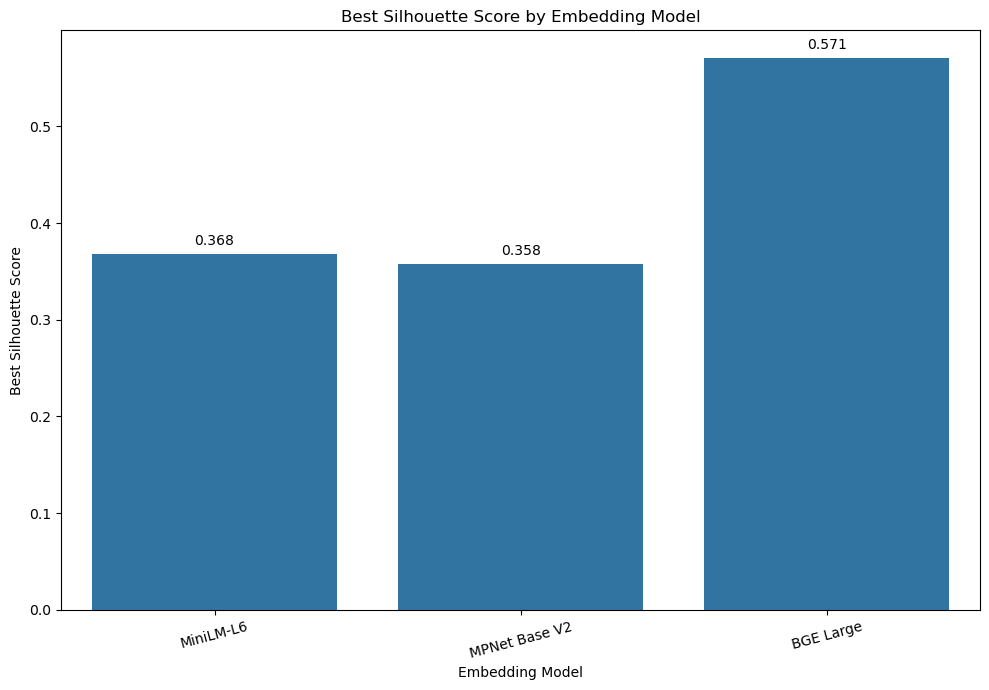

In [69]:
# Bar Plot — Best silhouette score per model
model_order = ["MiniLM-L6", "MPNet Base V2", "BGE Large"]

best_per_model = (
    optimized_results_df
    .sort_values("silhouette_score", ascending=False)
    .groupby("model_name", as_index=False)
    .first()
)

best_per_model["model_name"] = pd.Categorical(
    best_per_model["model_name"],
    categories= model_order,
    ordered=True
)

best_per_model = best_per_model.sort_values("model_name")

plt.figure(figsize=(10, 7))
ax = sns.barplot(data=best_per_model, x="model_name", y="silhouette_score")

# Adding value labels on top of bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), 
                textcoords='offset points')

plt.title("Best Silhouette Score by Embedding Model")
plt.xlabel("Embedding Model")
plt.ylabel("Best Silhouette Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

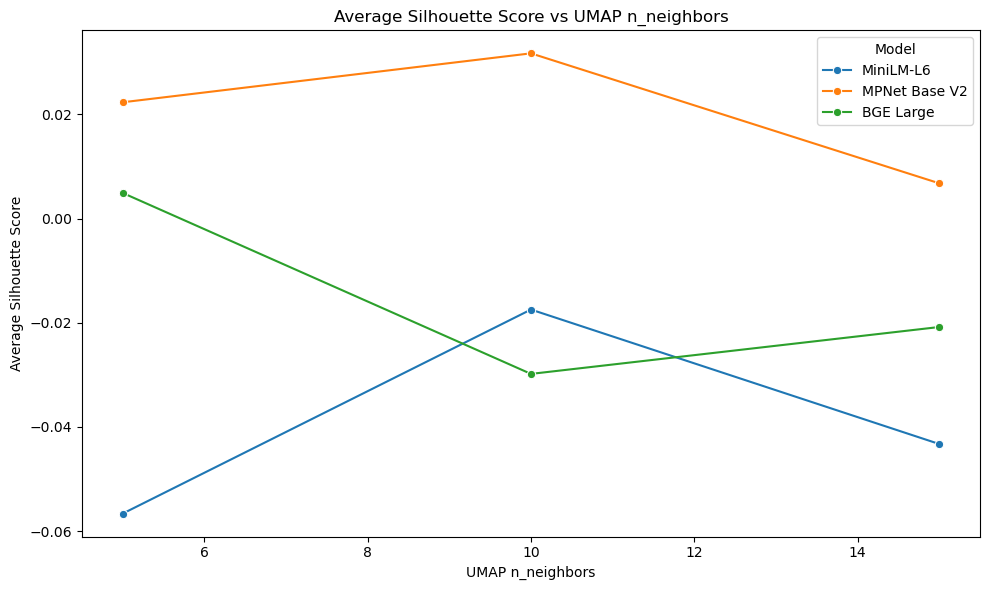

In [70]:
# Line Plot — Silhouette vs UMAP n_neighbors (averaged across other params)
neighbors_plot_df = (
    optimized_results_df
    .groupby(["model_name", "umap_n_neighbors"], as_index=False)["silhouette_score"]
    .mean()
)

neighbors_plot_df["model_name"] = pd.Categorical(
    neighbors_plot_df["model_name"],
    categories=model_order,
    ordered=True
)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=neighbors_plot_df,
    x="umap_n_neighbors",
    y="silhouette_score",
    hue="model_name",
    marker="o"
)
plt.title("Average Silhouette Score vs UMAP n_neighbors")
plt.xlabel("UMAP n_neighbors")
plt.ylabel("Average Silhouette Score")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

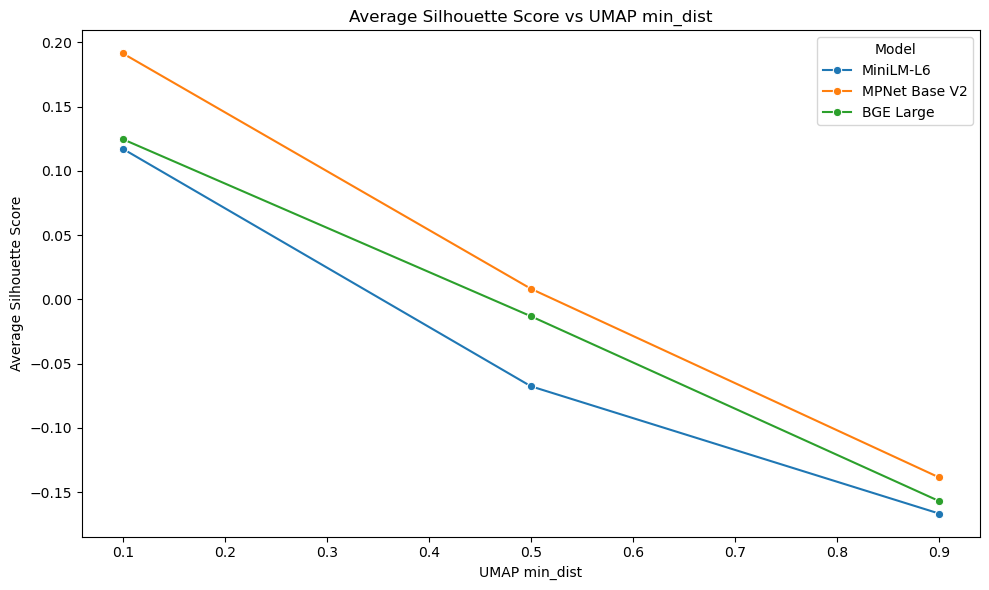

In [71]:
# Line Plot — Silhouette vs UMAP min_dist
min_dist_plot_df = (
    optimized_results_df
    .groupby(["model_name", "umap_min_dist"], as_index=False)["silhouette_score"]
    .mean()
)

min_dist_plot_df["model_name"] = pd.Categorical(
    min_dist_plot_df["model_name"],
    categories=model_order,
    ordered=True
)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=min_dist_plot_df,
    x="umap_min_dist",
    y="silhouette_score",
    hue="model_name",
    marker="o"
)
plt.title("Average Silhouette Score vs UMAP min_dist")
plt.xlabel("UMAP min_dist")
plt.ylabel("Average Silhouette Score")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

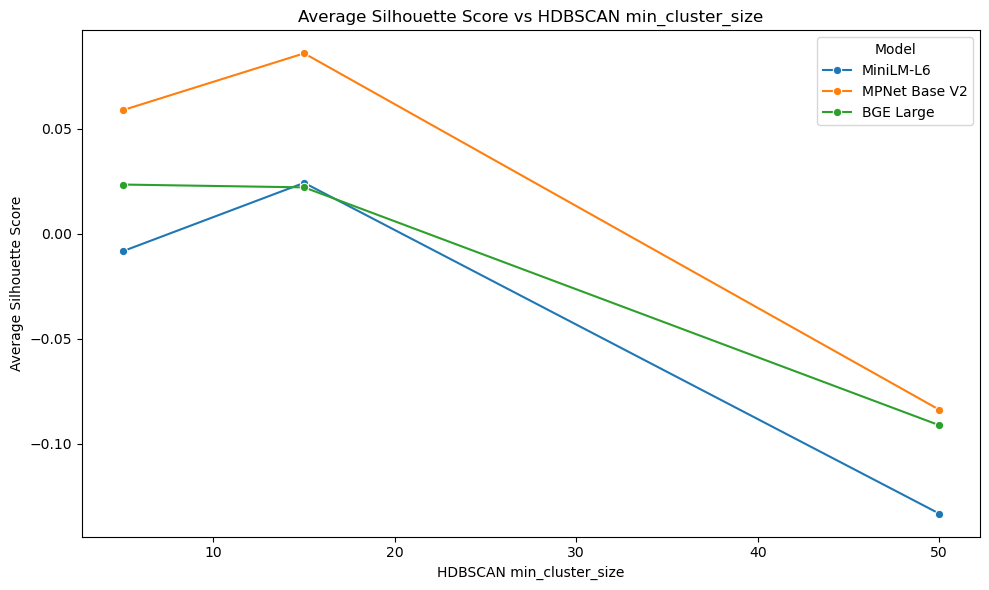

In [72]:
# Line Plot — Silhouette vs HDBSCAN min_cluster_size
cluster_size_plot_df = (
    optimized_results_df
    .groupby(["model_name", "hdbscan_min_cluster_size"], as_index=False)["silhouette_score"]
    .mean()
)

cluster_size_plot_df["model_name"] = pd.Categorical(
    cluster_size_plot_df["model_name"],
    categories=model_order,
    ordered=True
)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=cluster_size_plot_df,
    x="hdbscan_min_cluster_size",
    y="silhouette_score",
    hue="model_name",
    marker="o"
)
plt.title("Average Silhouette Score vs HDBSCAN min_cluster_size")
plt.xlabel("HDBSCAN min_cluster_size")
plt.ylabel("Average Silhouette Score")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

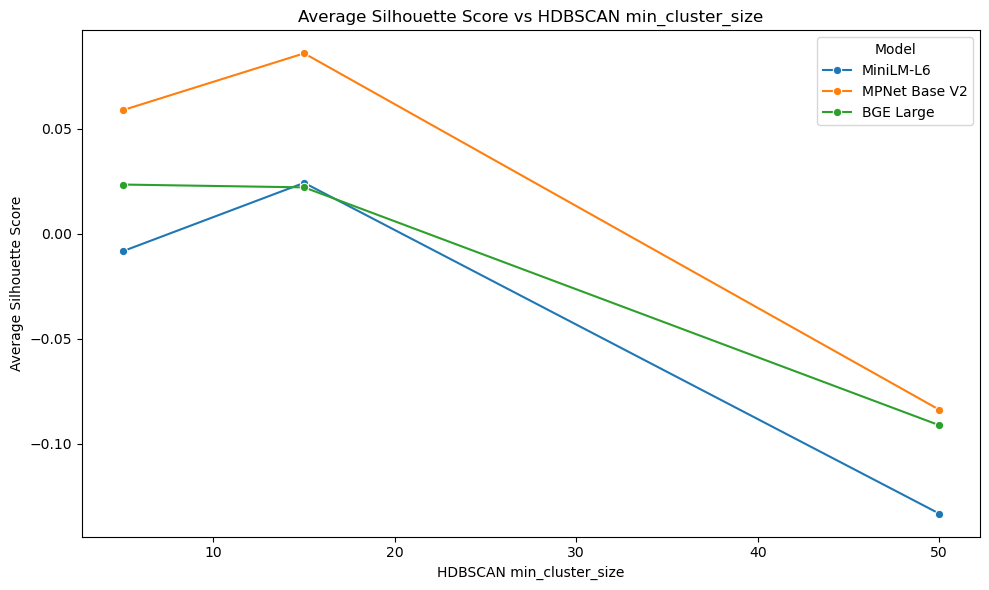

In [73]:
# Line Plot — Silhouette vs HDBSCAN min_cluster_size
cluster_size_plot_df = (
    optimized_results_df
    .groupby(["model_name", "hdbscan_min_cluster_size"], as_index=False)["silhouette_score"]
    .mean()
)

cluster_size_plot_df["model_name"] = pd.Categorical(
    cluster_size_plot_df["model_name"],
    categories=model_order,
    ordered=True
)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=cluster_size_plot_df,
    x="hdbscan_min_cluster_size",
    y="silhouette_score",
    hue="model_name",
    marker="o"
)
plt.title("Average Silhouette Score vs HDBSCAN min_cluster_size")
plt.xlabel("HDBSCAN min_cluster_size")
plt.ylabel("Average Silhouette Score")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

In [74]:
# Best Parameter Summary Table
best_summary = (
    optimized_results_df
    .sort_values("silhouette_score", ascending=False)
    .groupby("model_name", as_index=False)
    .first()
)

# best_summary["model_name"] = pd.Categorical(
#     best_summary["model_name"],
#     categories=model_order,
#     ordered=True
# )

best_summary = best_summary.sort_values("model_name")
print("--"*50)
print("Best Parameter Summary for each model")
print("--"*50)
best_summary

----------------------------------------------------------------------------------------------------
Best Parameter Summary for each model
----------------------------------------------------------------------------------------------------


,model_name,umap_metric,umap_n_neighbors,umap_min_dist,hdbscan_metric,hdbscan_min_cluster_size,hdbscan_min_samples,silhouette_score
0,BGE Large,euclidean,5,0.1,manhattan,5,5,0.570875
1,MPNet Base V2,euclidean,5,0.1,euclidean,5,1,0.357840
2,MiniLM-L6,euclidean,5,0.1,manhattan,5,1,0.368255


### **2. Topic Representation with c-TF-IDF**

#### **2.1 Stop Word Construction**

In [75]:
# loading stopwords from both sklearn and nltk
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.corpus import stopwords

nltk_stopwords = set(stopwords.words('english'))
sklearn_stopwords = set(ENGLISH_STOP_WORDS)
nltk_unique = nltk_stopwords.difference(sklearn_stopwords)

# List of common words to be removed from full_text_clean column
common_word_list = {'followers', 'instagram', 'facebook', 'like', 'messages', 'support',
                    'sitemap', 'free', 'faq', 'twitter', 'search', 'subscribe', 'youtube', 
                    'feedback', 'linkedin', 'demo', 'menu', 'following', 'unsubscribe', 
                    'snapchat', 'tiktok', 'whatsapp', '1xbet',
                    'profile', 'share', 'reddit', 'download', 'settings', 'notifications', 'qa', 'people'}

# Common phrases to remove
phrase_list = ["find out more", "join now","terms & conditions", "terms and conditions","all rights reserved","free trial", 
             "click here", "about us", "contact us","terms of service", "privacy policy", "help center", "our story","our team",
             "read more", "learn more", "get started", "download now", "sign up", "log in", 'december december']

stop_words_corpus = sklearn_stopwords.union(nltk_unique).union(common_word_list).union(phrase_list)

print("--"*50)
print("Total Stop Words in the Corpus:", len(stop_words_corpus), "\nSample Stop Words:", list(stop_words_corpus)[:10], "...")
print("--"*50)

----------------------------------------------------------------------------------------------------
Total Stop Words in the Corpus: 449 
Sample Stop Words: ['thereafter', 'somehow', 'her', "i'll", 'upon', 'it', 'demo', 'about us', 'else', 'you'] ...
----------------------------------------------------------------------------------------------------


In [76]:
def compute_ctfidf(documents, clusters, top_n=10, true_labels = None):
    """
    Compute c-TF-IDF: class-based TF-IDF for topic representation.
    
    Parameters:
    -----------
    documents : list of str — all document texts
    clusters : array-like — cluster assignment per document
    top_n : int — number of top keywords per topic
    
    Returns:
    --------
    dict mapping cluster_id → list of (word, score) tuples
    """
    results = {}
    # Group documents by cluster
    cluster_docs = {}
    for doc, cluster_id in zip(documents, clusters):
        if cluster_id == -1:
            continue  # skip outliers
        if cluster_id not in cluster_docs:
            cluster_docs[cluster_id] = []
        cluster_docs[cluster_id].append(doc)
    
    # Concatenate documents per cluster into single "class documents"
    cluster_ids = sorted(cluster_docs.keys())
    class_documents = [' '.join(cluster_docs[cid]) for cid in cluster_ids]
    
    # Fit CountVectorizer on the class documents
    vectorizer = CountVectorizer(
        max_features=10000,
        stop_words='english',
        min_df=2,
        ngram_range=(1, 2)
    )
    tf = vectorizer.fit_transform(class_documents)
    
    # c-TF-IDF computation
    # TF: word count per class / total words in class
    tf_dense = tf.toarray().astype(float)
    tf_normalized = tf_dense / tf_dense.sum(axis=1, keepdims=True)
    
    # IDF: log(1 + total docs / docs containing word)
    n_classes = len(class_documents)
    df_count = (tf_dense > 0).sum(axis=0)
    idf = np.log(1 + n_classes / (df_count + 1))
    
    # c-TF-IDF = TF * IDF
    ctfidf = tf_normalized * idf
    
    # Extract top keywords per cluster
    feature_names = vectorizer.get_feature_names_out()
    topic_keywords = {}
    
    for idx, cid in enumerate(cluster_ids):
        scores = ctfidf[idx]
        top_indices = scores.argsort()[-top_n:][::-1]
        keywords = [(feature_names[i], scores[i]) for i in top_indices]
        topic_keywords[cid] = keywords
    
    # Computing ari and nmi scores
    ari_score = adjusted_rand_score(true_labels, clusters)
    nmi_score = normalized_mutual_info_score(true_labels, clusters)
    print(f"Adjusted Rand Index (ARI): {ari_score:.4f}")
    print(f"Normalized Mutual Information (NMI): {nmi_score:.4f}")

    return topic_keywords, ari_score, nmi_score

In [77]:
user_models

{'MiniLM-L6': 'model/mini_lm_embeddings.npy',
 'MPNet Base V2': 'model/mpnet_base_v2_embeddings.npy',
 'BGE Large': 'model/bge_large_embeddings.npy'}

In [78]:
best_summary

,model_name,umap_metric,umap_n_neighbors,umap_min_dist,hdbscan_metric,hdbscan_min_cluster_size,hdbscan_min_samples,silhouette_score
0,BGE Large,euclidean,5,0.1,manhattan,5,5,0.570875
1,MPNet Base V2,euclidean,5,0.1,euclidean,5,1,0.357840
2,MiniLM-L6,euclidean,5,0.1,manhattan,5,1,0.368255


----------------------------------------------------------------------------------------------------
Processing model: BGE Large
Clustering Results:
  Topics discovered: 2
  Outliers (topic -1): 0 (0.0%)
  Documents clustered: 596
  Silhouette Score: 0.5709
Adjusted Rand Index (ARI): 0.0049
Normalized Mutual Information (NMI): 0.0179
Topic representations generated for 2 topics.

Topic 0 (6 docs):
  Keywords: nasa | da | ltimas | link | pinterest mail | mail | facebook pinterest
Topic 1 (590 docs):
  Keywords: home | new | contact | search | services | information | business


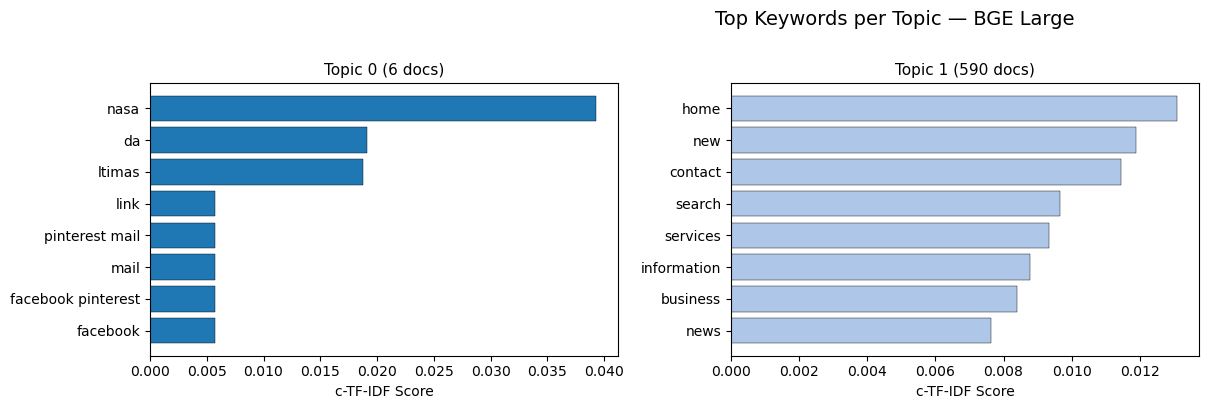

----------------------------------------------------------------------------------------------------


----------------------------------------------------------------------------------------------------
Processing model: MPNet Base V2
Clustering Results:
  Topics discovered: 56
  Outliers (topic -1): 53 (8.9%)
  Documents clustered: 543
  Silhouette Score: 0.3578
Adjusted Rand Index (ARI): 0.0232
Normalized Mutual Information (NMI): 0.2075
Topic representations generated for 56 topics.

Topic 0 (7 docs):
  Keywords: nasa | ltimas | da | pinterest mail | instruments | link facebook | facebook pinterest
Topic 1 (9 docs):
  Keywords: september august | june april | july june | june | october september | august | february
Topic 2 (5 docs):
  Keywords: sydney | st | park | ale | henderson | victoria | ave
Topic 3 (6 docs):
  Keywords: frankfurt | hotels | pm pm | vietnam | pm | finalist | urban
Topic 4 (9 docs):
  Keywords: xbet | hair | casino | xbet xbet | wishlist | proof | perfume
Topi

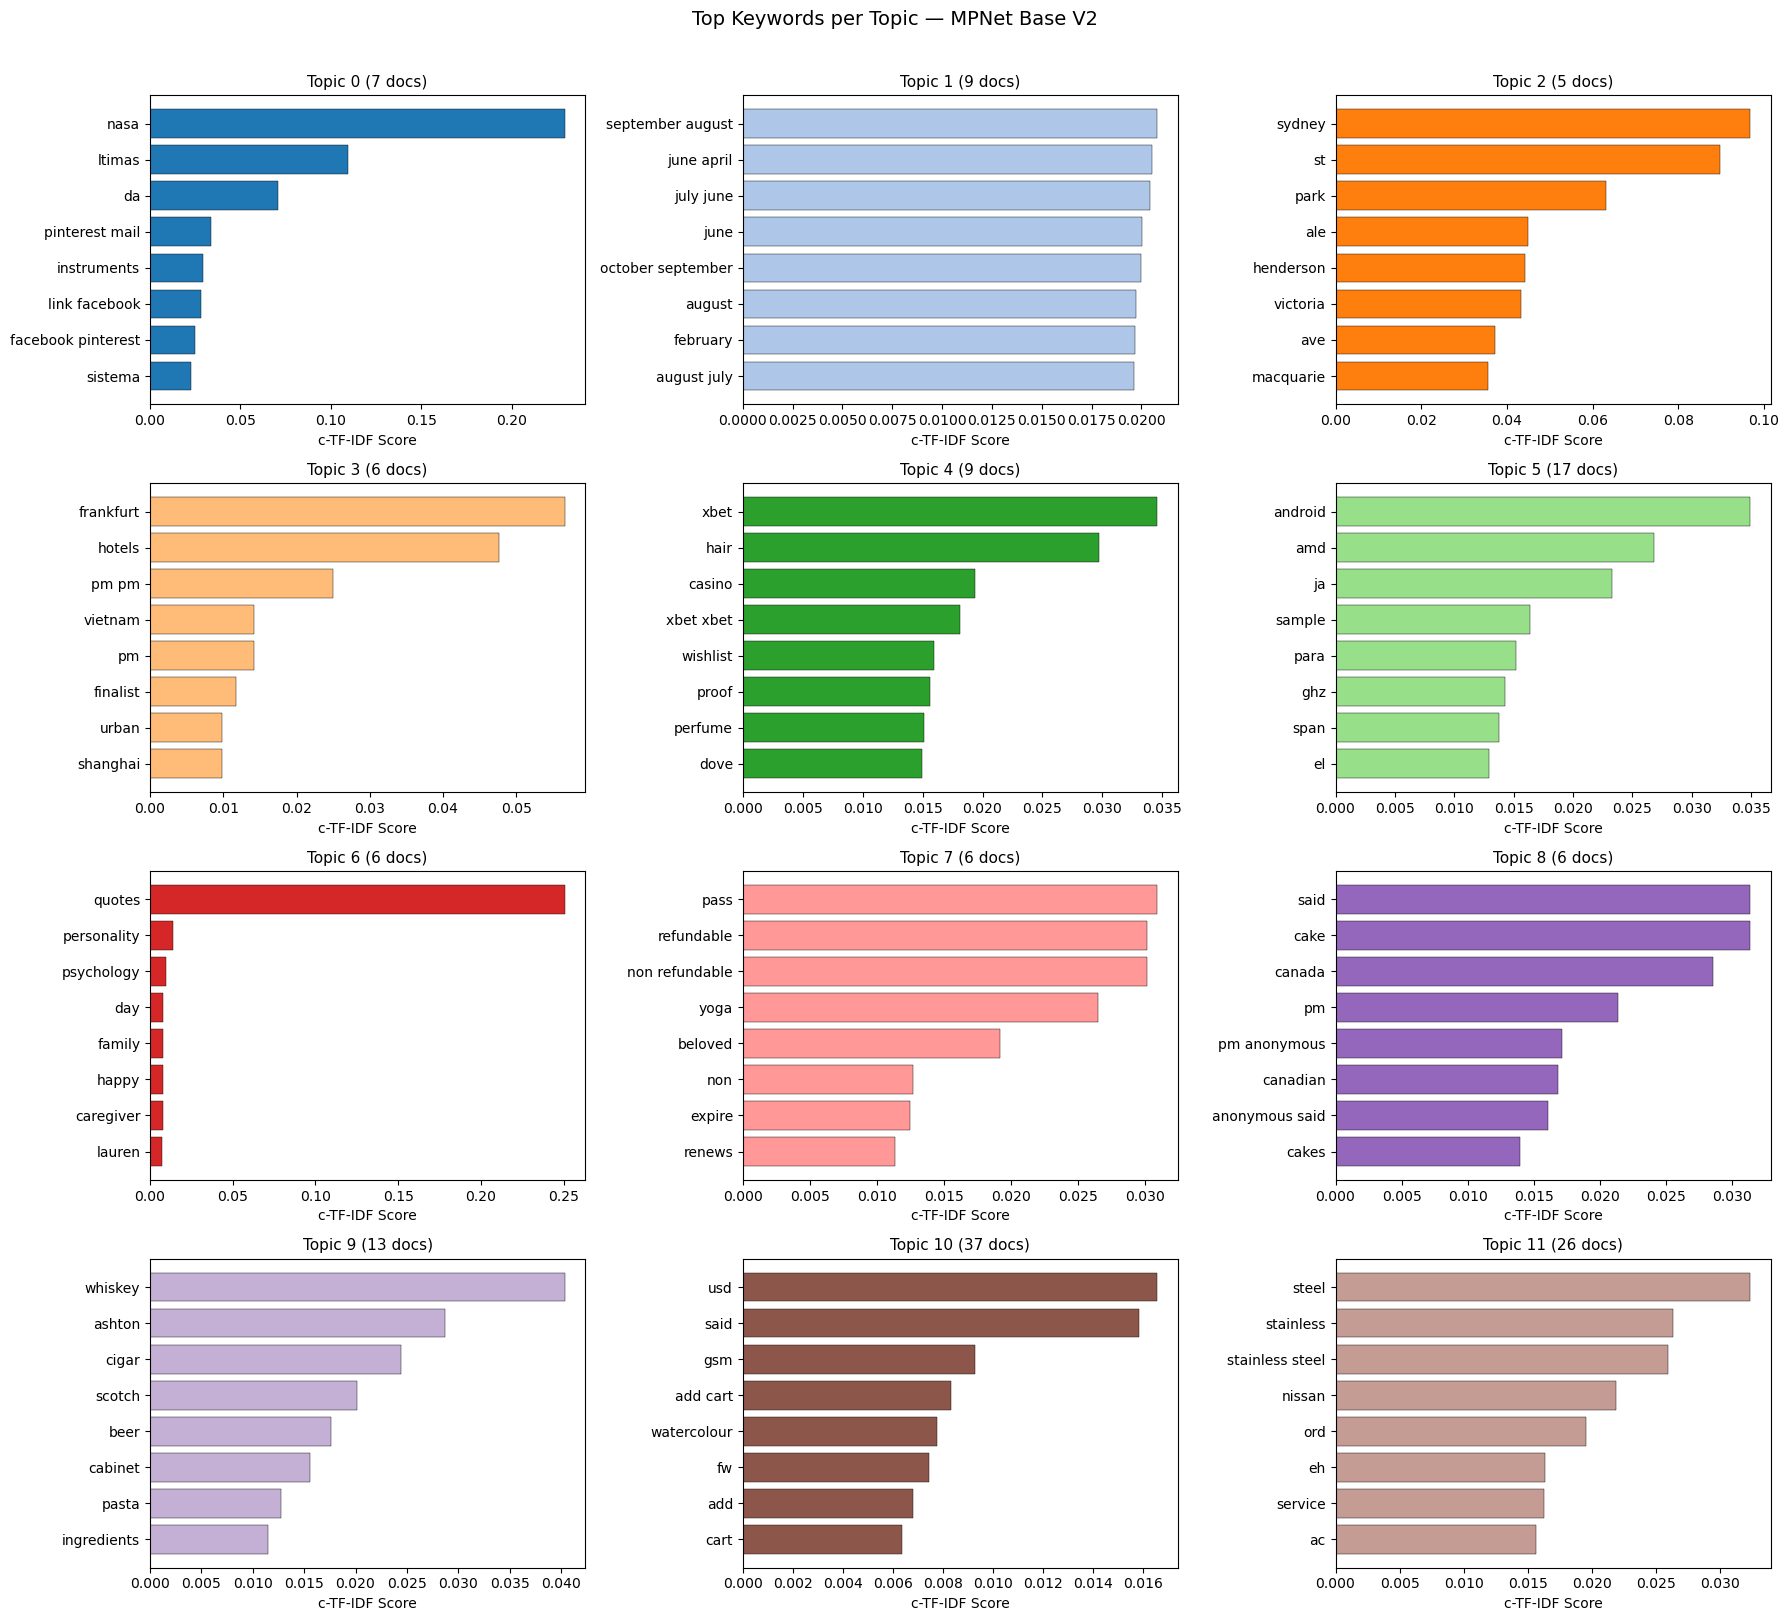

----------------------------------------------------------------------------------------------------


----------------------------------------------------------------------------------------------------
Processing model: MiniLM-L6
Clustering Results:
  Topics discovered: 54
  Outliers (topic -1): 70 (11.7%)
  Documents clustered: 526
  Silhouette Score: 0.3683
Adjusted Rand Index (ARI): 0.0313
Normalized Mutual Information (NMI): 0.2207
Topic representations generated for 54 topics.

Topic 0 (15 docs):
  Keywords: said | giveaway | love | quilt | fabrics | mug | january
Topic 1 (12 docs):
  Keywords: aud | eur | usd | fw | dress | fr | gbp
Topic 2 (14 docs):
  Keywords: nasa | da | para | la | pinterest mail | el | link facebook
Topic 3 (6 docs):
  Keywords: drama | korea | soundtrack | singers | ebook | artists | immediately
Topic 4 (24 docs):
  Keywords: quotes | carlisle | school | middle school | results | meet | elementary
Topic 5 (8 docs):
  Keywords: rounds | instructional | so

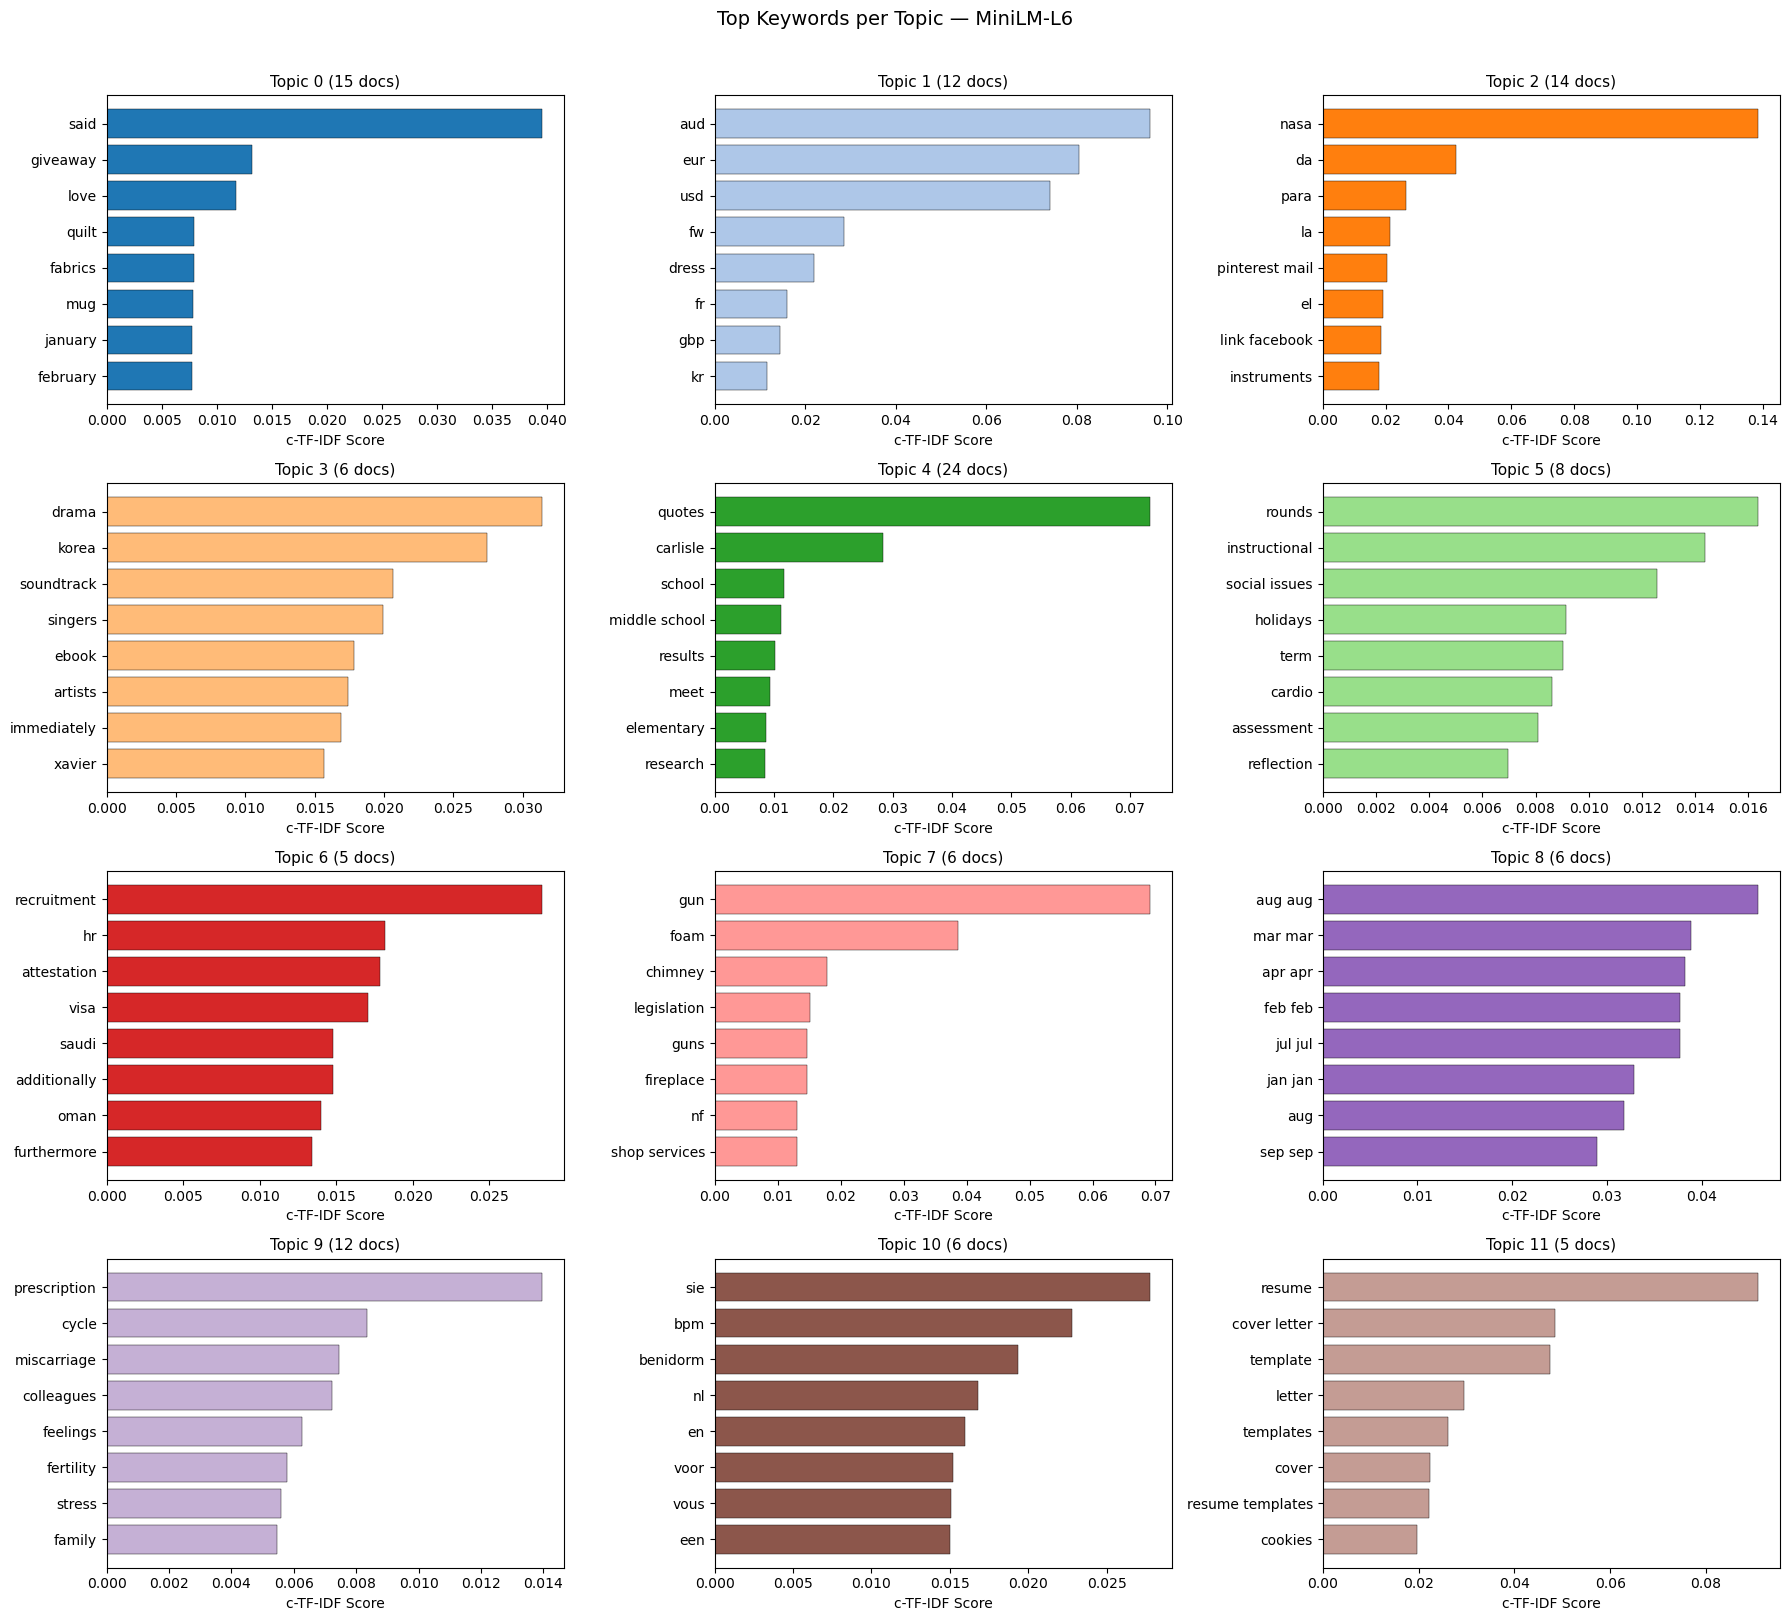

----------------------------------------------------------------------------------------------------




In [85]:
# Running and plotting model and there cluster representations

true_labels = data_label["manual_label_final"].to_list()

final_results = {}

for _, row in best_summary.iterrows():
    print("--"*50)
    print(f"Processing model: {row['model_name']}")
    model_embeddings = np.load(user_models[row['model_name']])

    # Umap and HDBSCAN with best parameters for the model
    reducer = umap.UMAP(
        n_neighbors= row['umap_n_neighbors'],
        min_dist= row['umap_min_dist'], 
        metric= row['umap_metric'], 
        n_components=5, n_jobs=1, random_state=42
        )
    embedding_5d = reducer.fit_transform(model_embeddings)
    
    # HDBSCAN with best parameters for the model
    hdbscan_model = hdbscan.HDBSCAN(
        min_cluster_size= row['hdbscan_min_cluster_size'], 
        min_samples= row['hdbscan_min_samples'], 
        metric= row['hdbscan_metric']
    )

    clusterer = hdbscan_model.fit_predict(embedding_5d)

    n_clusters = len(set(clusterer)) - (1 if -1 in clusterer else 0)
    n_outliers = (clusterer == -1).sum()
    pct_outliers = n_outliers / len(clusterer) * 100

    print(f"Clustering Results:")
    print(f"  Topics discovered: {n_clusters}")
    print(f"  Outliers (topic -1): {n_outliers} ({pct_outliers:.1f}%)")
    print(f"  Documents clustered: {len(clusterer) - n_outliers}")
    print(f"  Silhouette Score: {row['silhouette_score']:.4f}")

    top_words, ari_score, nmi_score = compute_ctfidf(input_text, clusterer, top_n=10, true_labels=true_labels)

    print(f"Topic representations generated for {len(top_words)} topics.\n")
    for count, topic_id in enumerate(sorted(top_words.keys())):
        keywords = top_words[topic_id]
        size = (clusterer == topic_id).sum()
        keyword_str = ' | '.join([f"{word}" for word, score in keywords[:7]])
        print(f"Topic {topic_id} ({size} docs):")
        print(f"  Keywords: {keyword_str}")
        
        if count >= 5:  # Limit to first 5 topics for brevity
            break

    
    # Visualize top keywords per topic as bar charts
    n_topics_to_show = min(len(top_words), 12)
    topic_ids = sorted(top_words.keys())[:n_topics_to_show]

    cols = 3
    rows = (n_topics_to_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
    axes = axes.flatten() if n_topics_to_show > 1 else [axes]

    for idx, topic_id in enumerate(topic_ids):
        keywords = top_words[topic_id][:8]
        words = [w for w, s in keywords][::-1]
        scores = [s for w, s in keywords][::-1]
        size = (clusterer == topic_id).sum()
        
        axes[idx].barh(words, scores, color=plt.cm.tab20(idx / 20), edgecolor='black', linewidth=0.3)
        axes[idx].set_title(f'Topic {topic_id} ({size} docs)', fontsize=11)
        axes[idx].set_xlabel('c-TF-IDF Score')

    # Hide empty subplots
    for idx in range(n_topics_to_show, len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle(f'Top Keywords per Topic — {row["model_name"]}', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
    
    print("--"*50)
    print("\n")

    final_results[row['model_name']] = {
        "dimensions": model_embeddings.shape[1],
        "documents_clustered": len([x for x in clusterer if x != -1]),
        "silhouette_score": row['silhouette_score'],
        "outlier_percentage": pct_outliers,
        "topics_discovered": n_clusters,
        "ari_score": ari_score,
        "nmi_score": nmi_score

    }

final_results_df = pd.DataFrame(final_results).T.sort_values(by="silhouette_score", ascending=False)


In [86]:
# The best silhouette scores for each model are:
print("--"*50)
print("Final Results Summary")
print("--"*50)
final_results_df

----------------------------------------------------------------------------------------------------
Final Results Summary
----------------------------------------------------------------------------------------------------


,dimensions,documents_clustered,silhouette_score,outlier_percentage,topics_discovered,ari_score,nmi_score
BGE Large,1024.0,596.0,0.570875,0.000000,2.0,0.004894,0.017865
MiniLM-L6,384.0,526.0,0.368255,11.744966,54.0,0.031338,0.220700
MPNet Base V2,768.0,543.0,0.357840,8.892617,56.0,0.023232,0.207472


-------

## **Conclusion**

Based on the above table output it very clear that we have low ARI and NMI (near 0). The model's are finding structure, it is not the structure you expected. While BGE Large achieves the highest Silhouette Score (0.57), its near-zero ARI and NMI indicate it failed to capture the underlying ground-truth categories, instead collapsing the 596 documents into only 2 broad topics. In contrast, MiniLM-L6 and MPNet Base V2 demonstrate significantly better alignment with the intended labels, as evidenced by their higher NMI scores (0.20–0.22) and more granular discovery of over 50 topics. Despite the higher outlier rates and lower internal cohesion scores for these smaller models, they are far more effective at distinguishing the specific semantic structures required for this dataset. 

#### **Final Verdict:**
The clusters that models have created has almost no overlap with our ground truth labels.
